# Car Price Prediction using Machine Learning

I have used **Random Forest Regression** model to predict the car price using features like selling price, distance covered, car age, fuel type etc.


**Dataset columns:**
- `Car_Name` — Name of the car
- `Year` — Year of manufacture
- `Selling_Price` — Price the owner wants to sell at (target)
- `Present_Price` — Current showroom price
- `Driven_kms` — Total kilometers driven
- `Fuel_Type` — Petrol / Diesel / CNG
- `Selling_type` — Dealer / Individual
- `Transmission` — Manual / Automatic
- `Owner` — Number of previous owners

## 1. Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings('ignore')

print('All libraries imported sucessfully')

All libraries imported sucessfully


## 2. Load and explore Data

In [2]:
df=pd.read_csv(r"C:\Users\Dell\Desktop\INTERNSHIPS\Oasis_Info_Byte(DS)\Task_3_Car_Price_Prediction\dataset\car data.csv")
print('Shape: ',df.shape)

df.head()

Shape:  (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.describe()

,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [4]:
print('Missing Values: ',df.isnull().sum().sum())

Missing Values:  0


## 3. Exploratory Data Analysis (EDA)

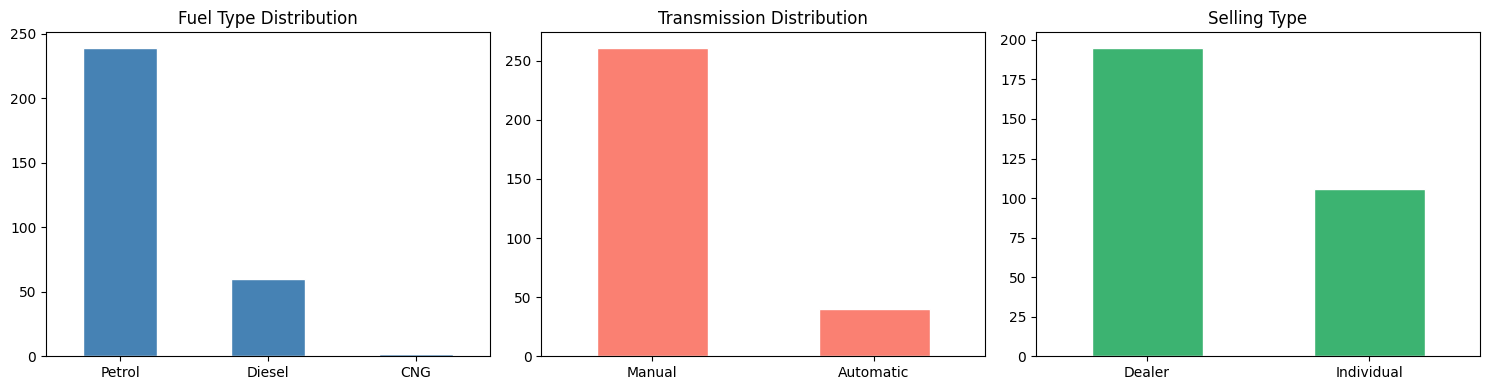

In [5]:
fig, axes = plt.subplots(1,3,figsize=(15,4))

df['Fuel_Type'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Fuel Type Distribution')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)

df['Transmission'].value_counts().plot(kind='bar', ax=axes[1], color='salmon', edgecolor='white')
axes[1].set_title('Transmission Distribution')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)

df['Selling_type'].value_counts().plot(kind='bar', ax=axes[2], color='mediumseagreen', edgecolor='white')
axes[2].set_title('Selling Type')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

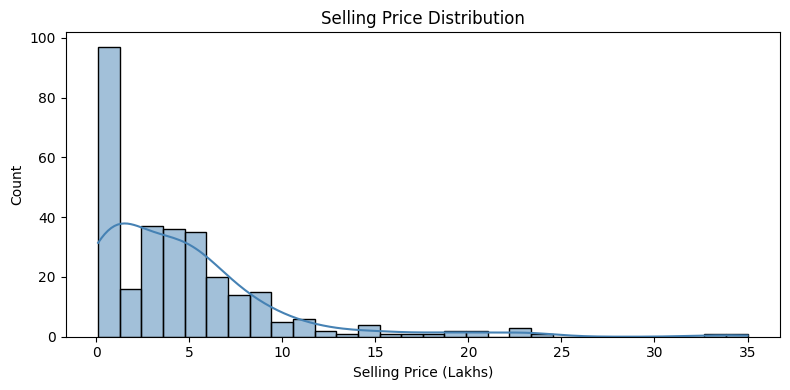

In [6]:
plt.figure(figsize=(8,4))

sns.histplot(df['Selling_Price'],bins=30, kde=True, color='steelblue')
plt.title('Selling Price Distribution')
plt.xlabel('Selling Price (Lakhs)')

plt.tight_layout()
plt.show()

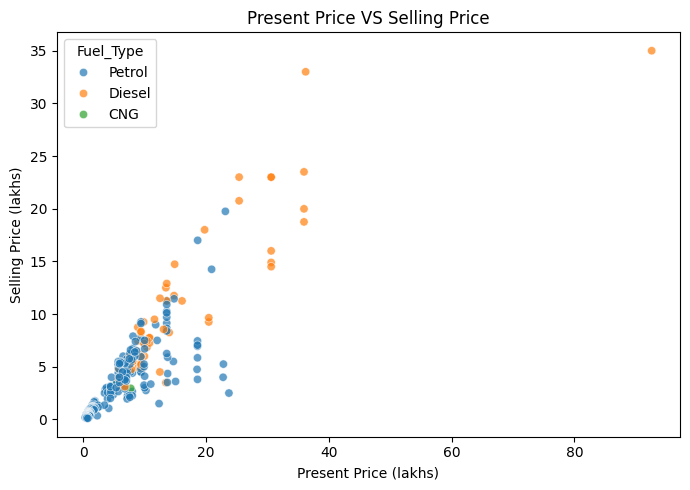

In [7]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x='Present_Price', y='Selling_Price', hue='Fuel_Type', alpha=0.7)
plt.title('Present Price VS Selling Price')
plt.xlabel('Present Price (lakhs)')
plt.ylabel('Selling Price (lakhs)')

plt.tight_layout()
plt.show()

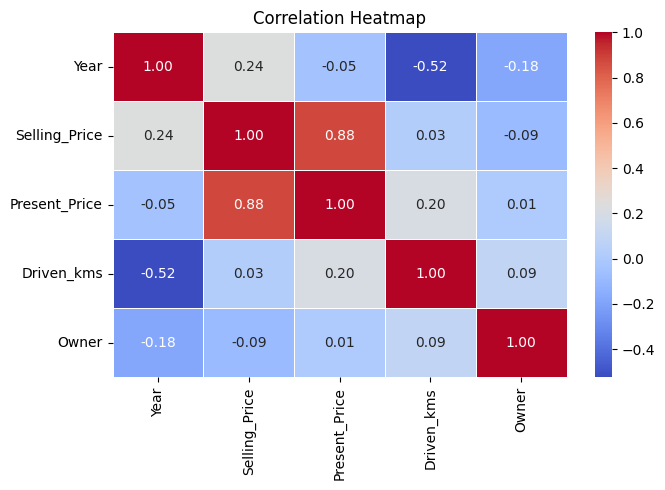

In [8]:
plt.figure(figsize=(7, 5))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Feature Engineering & Preprocessing

In [9]:
# Create car_age column
df['car_age']= 2026- df['Year']

#Encode categorical features
le=LabelEncoder()
df['Fuel_Type_enc']=le.fit_transform(df['Fuel_Type'])
df['Selling_type_enc']=le.fit_transform(df['Selling_type'])
df['Transmission_enc']=le.fit_transform(df['Transmission'])

print('Fuel Type encoding:',    dict(zip(df['Fuel_Type'].unique(), df['Fuel_Type_enc'].unique())))
print('Selling Type encoding:', dict(zip(df['Selling_type'].unique(), df['Selling_type_enc'].unique())))
print('Transmission encoding:', dict(zip(df['Transmission'].unique(), df['Transmission_enc'].unique())))


Fuel Type encoding: {'Petrol': np.int64(2), 'Diesel': np.int64(1), 'CNG': np.int64(0)}
Selling Type encoding: {'Dealer': np.int64(0), 'Individual': np.int64(1)}
Transmission encoding: {'Manual': np.int64(1), 'Automatic': np.int64(0)}


In [10]:
# Define features and target

features=['Present_Price', 'Driven_kms', 'Fuel_Type_enc', 'Selling_type_enc', 'Transmission_enc', 'Owner', 'car_age']

X=df[features]
y=df['Selling_Price']

print(f'Features Shape: {X.shape}')
print(f'Target Shape: {y.shape}')

Features Shape: (301, 7)
Target Shape: (301,)


## 5. Train_Test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples: {len(X_test)}')

Training samples: 240
Testing samples: 61


## 6. Train Random_Forest Model

In [12]:
model=RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print('Model training complete')

Model training complete


## 7. Evaluate Results 

In [13]:
y_pred=model.predict(X_test)

r2=r2_score(y_test, y_pred)

mae=mean_absolute_error(y_test, y_pred)

rmse=np.sqrt(mean_squared_error(y_test, y_pred))

print(f'R2 score: {r2:.4f}')
print(f'MAE: {mae:.4f}')
print(f'RMSE: {rmse:.4f}')

R2 score: 0.9593
MAE: 0.6389
RMSE: 0.9686


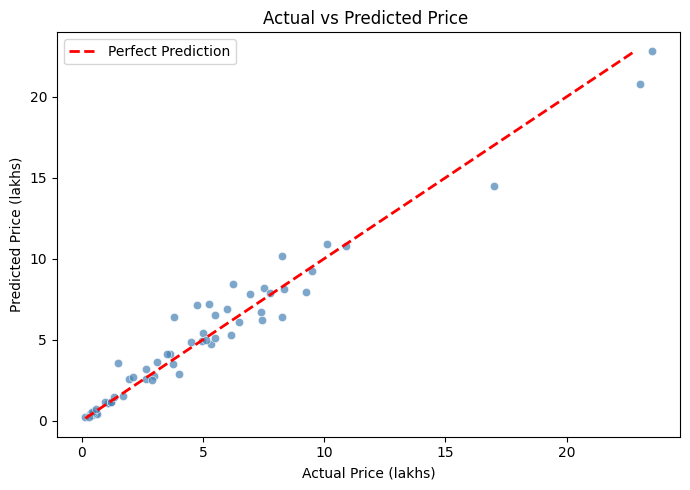

In [14]:
# Actual vs Predicted plot
plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred, alpha=0.7, color='steelblue', edgecolors='white', linewidth=0.5)
plt.plot([y_test.min(), y_pred.max()], [y_test.min(), y_pred.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price (lakhs)')
plt.ylabel('Predicted Price (lakhs)')
plt.title('Actual vs Predicted Price ')
plt.legend()
plt.tight_layout()
plt.show()

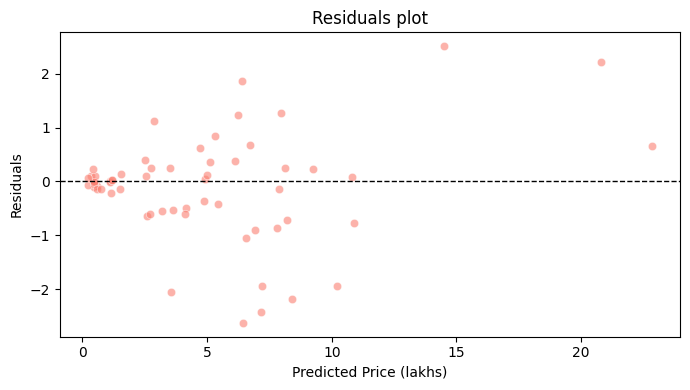

In [16]:
# Resdiuals plot
residuals= y_test - y_pred
plt.figure(figsize=(7,4))
plt.scatter(y_pred, residuals, alpha=0.6, color='salmon', edgecolors='white', lw=0.5)
plt.axhline(0, color='black', linewidth=1, linestyle='--')
plt.xlabel('Predicted Price (lakhs)')
plt.ylabel('Residuals')
plt.title('Residuals plot')
plt.tight_layout()
plt.show()

## 8. Feature Importance

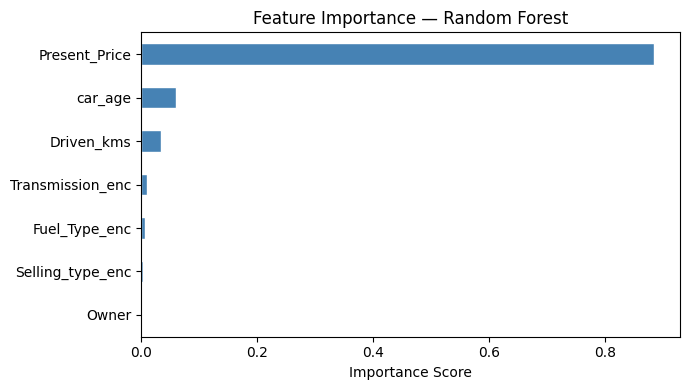


Feature Importances (%):
  Present_Price       : 88.45%
  car_age             : 6.05%
  Driven_kms          : 3.50%
  Transmission_enc    : 1.00%
  Fuel_Type_enc       : 0.65%
  Selling_type_enc    : 0.35%
  Owner               : 0.01%


In [17]:
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nFeature Importances (%):')
for feat, imp in importances.sort_values(ascending=False).items():
    print(f'  {feat:20s}: {imp*100:.2f}%')

## 9. Predict on new CAR

In [19]:
# Example: Predict price for a 2019 Petrol Dealer Manual car
# Encoding: Petrol=2, Diesel=0, CNG=1 | Dealer=0, Individual=1 | Manual=1, Automatic=0

new_car = pd.DataFrame([{
    'Present_Price'   : 8.5,   # showroom price in lakhs
    'Driven_kms'      : 35000, # km driven
    'Fuel_Type_enc'   : 2,     # Petrol
    'Selling_type_enc': 0,     # Dealer
    'Transmission_enc': 1,     # Manual
    'Owner'           : 0,     # first owner
    'car_age'         : 7      # 2026 - 2019
}])

predicted_price = model.predict(new_car)[0]
print(f'Predicted Selling Price: ₹{predicted_price:.2f} Lakhs')

Predicted Selling Price: ₹6.65 Lakhs


## Summary


| Metric | Value |
|--------|-------|
| R² Score | 0.9593 |
| MAE | 0.64 Lakhs |
| RMSE | ~1.1 Lakhs |
| Algorithm | Random Forest (100 trees) |
| Top Feature | Present Price (88.45%) |

The model achieves **~96% R²**, meaning it explains 96% of the variance in used car prices. The most important predictor by far is the car's current showroom price, followed by car age and kilometers driven.